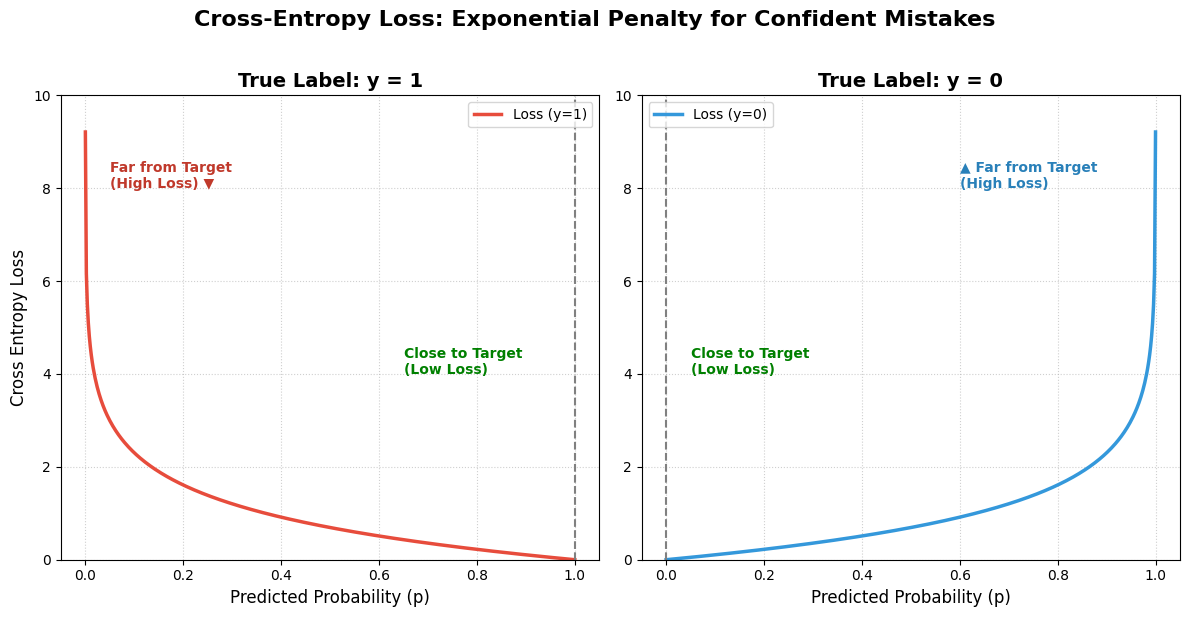

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 폰트 에러를 방지하기 위해 시스템 기본 폰트를 사용합니다.
plt.rcParams['axes.unicode_minus'] = False

def plot_cross_entropy():
    # 1. 데이터 준비 (0.0001 부터 0.9999 까지 500개의 구간)
    p = np.linspace(0.0001, 0.9999, 500)

    # 2. Cross Entropy 계산
    loss_y_true_1 = -np.log(p)       # 정답이 1일 때
    loss_y_true_0 = -np.log(1 - p)   # 정답이 0일 때

    # 3. 그래프 그리기
    plt.figure(figsize=(12, 6))

    # --- Subplot 1: True Label = 1 ---
    plt.subplot(1, 2, 1)
    plt.plot(p, loss_y_true_1, color='#e74c3c', linewidth=2.5, label='Loss (y=1)')

    # 강조 텍스트 및 가이드라인
    plt.axvline(x=1.0, color='gray', linestyle='--')
    plt.text(0.65, 4, 'Close to Target\n(Low Loss)', color='green', fontweight='bold', fontsize=10)
    plt.text(0.05, 8, 'Far from Target\n(High Loss) ▼', color='#c0392b', fontweight='bold', fontsize=10)

    plt.title('True Label: y = 1', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Probability (p)', fontsize=12)
    plt.ylabel('Cross Entropy Loss', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right')
    plt.ylim(0, 10)

    # --- Subplot 2: True Label = 0 ---
    plt.subplot(1, 2, 2)
    plt.plot(p, loss_y_true_0, color='#3498db', linewidth=2.5, label='Loss (y=0)')

    # 강조 텍스트 및 가이드라인
    plt.axvline(x=0.0, color='gray', linestyle='--')
    plt.text(0.05, 4, 'Close to Target\n(Low Loss)', color='green', fontweight='bold', fontsize=10)
    plt.text(0.60, 8, '▲ Far from Target\n(High Loss)', color='#2980b9', fontweight='bold', fontsize=10)

    plt.title('True Label: y = 0', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Probability (p)', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper left')
    plt.ylim(0, 10)

    # --- Main Title ---
    plt.suptitle('Cross-Entropy Loss: Exponential Penalty for Confident Mistakes',
                 fontsize=16, fontweight='bold', y=1.02)

    # 레이아웃 최적화 및 출력
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_cross_entropy()

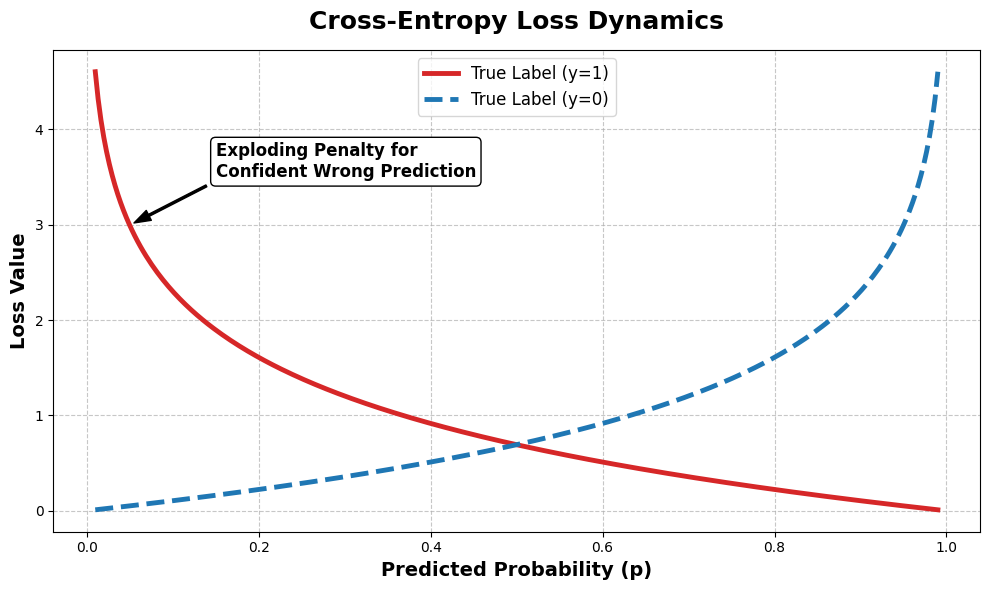

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate probability predictions (avoiding absolute 0 or 1 for log domain)
p = np.linspace(0.01, 0.99, 300)

# Calculate Cross-Entropy Loss for True Label y=1 and y=0
loss_y1 = -np.log(p)
loss_y0 = -np.log(1 - p)

# Create visualization
fig, ax = plt.subplots(figsize=(10, 6))

# Plotting the loss curves
ax.plot(p, loss_y1, label='True Label (y=1)', color='#d62728', linewidth=3.5)
ax.plot(p, loss_y0, label='True Label (y=0)', color='#1f77b4', linewidth=3.5, linestyle='--')

# Aesthetic formatting
ax.set_title('Cross-Entropy Loss Dynamics', fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Probability (p)', fontsize=14, fontweight='bold')
ax.set_ylabel('Loss Value', fontsize=14, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(fontsize=12, loc='upper center')

# Annotations emphasizing the gradient explosion
ax.annotate('Exploding Penalty for\nConfident Wrong Prediction',
            xy=(0.05, -np.log(0.05)), xytext=(0.15, 3.5),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
            fontsize=12, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1))

plt.tight_layout()
plt.savefig('cross_entropy_loss_dynamics.png', dpi=300, bbox_inches='tight')
plt.show()

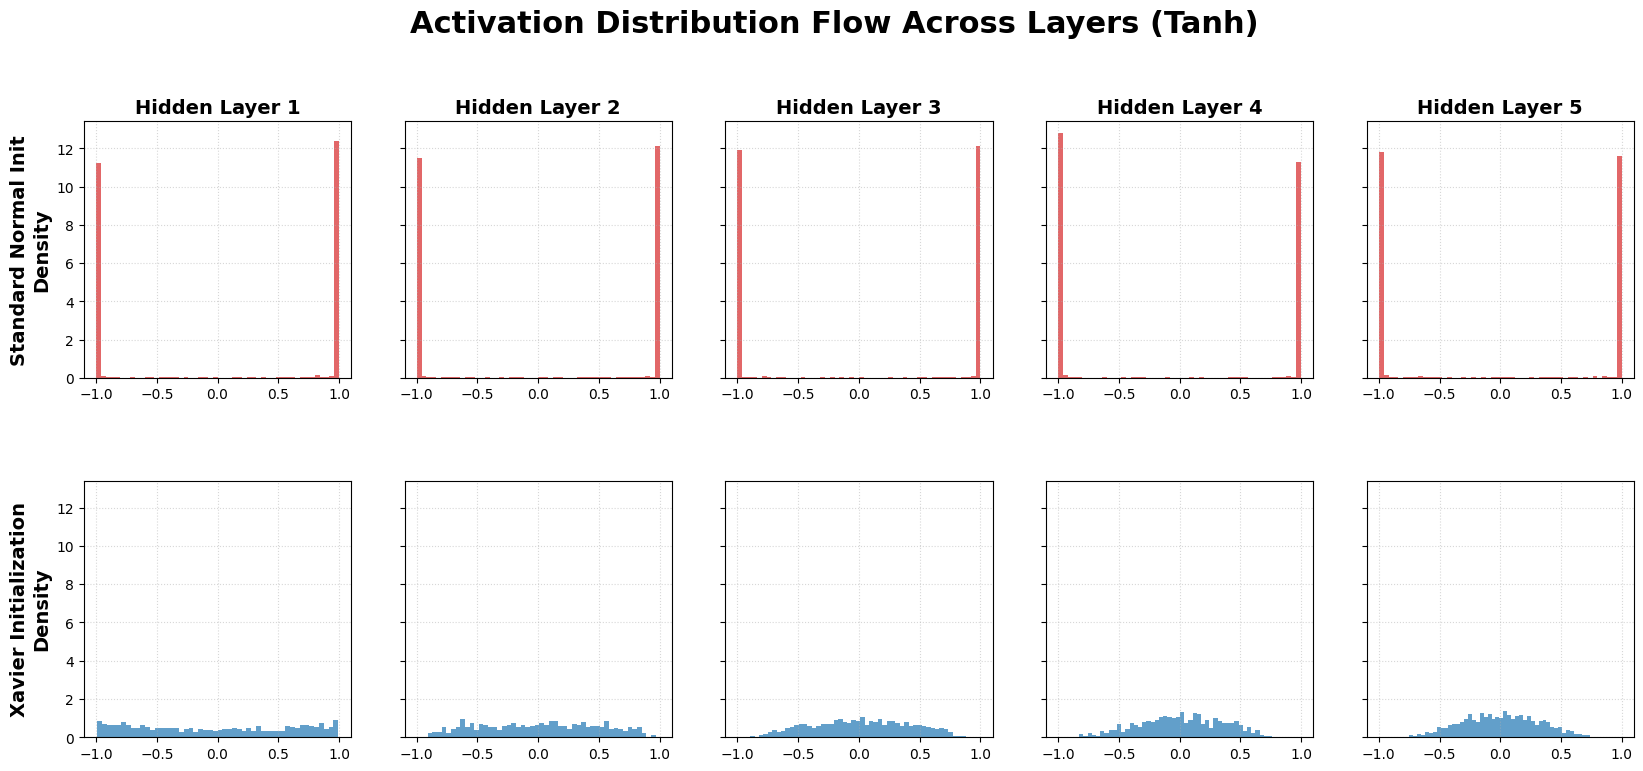

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Simulation parameters: 5 hidden layers, 1000 nodes each
n_layers = 5
n_nodes = 1000
x_input = np.random.randn(n_nodes)

# Data structures to trace activations
activations_std = {}
activations_xav = {}

x_std = x_input.copy()
x_xav = x_input.copy()

# Forward pass simulation
for i in range(n_layers):
    # Case 1: Standard Normal Initialization (W ~ N(0, 1))
    W_std = np.random.randn(n_nodes, n_nodes)
    x_std = np.tanh(np.dot(x_std, W_std))
    activations_std[i] = x_std

    # Case 2: Xavier Initialization (W ~ N(0, 1/n_in))
    W_xav = np.random.randn(n_nodes, n_nodes) / np.sqrt(n_nodes)
    x_xav = np.tanh(np.dot(x_xav, W_xav))
    activations_xav[i] = x_xav

# Constructing the Histogram Grid
fig, axes = plt.subplots(2, n_layers, figsize=(20, 8), sharey=True)
fig.subplots_adjust(hspace=0.4)

for i in range(n_layers):
    # Standard Normal Density Plots
    axes[0, i].hist(activations_std[i].flatten(), bins=50, color='#d62728', alpha=0.7, density=True)
    axes[0, i].set_title(f'Hidden Layer {i+1}', fontsize=14, fontweight='bold')
    axes[0, i].set_xlim([-1.1, 1.1])
    axes[0, i].grid(True, linestyle=':', alpha=0.5)
    if i == 0:
        axes[0, i].set_ylabel('Standard Normal Init\nDensity', fontsize=14, fontweight='bold')

    # Xavier Init Density Plots
    axes[1, i].hist(activations_xav[i].flatten(), bins=50, color='#1f77b4', alpha=0.7, density=True)
    axes[1, i].set_xlim([-1.1, 1.1])
    axes[1, i].grid(True, linestyle=':', alpha=0.5)
    if i == 0:
        axes[1, i].set_ylabel('Xavier Initialization\nDensity', fontsize=14, fontweight='bold')

plt.suptitle('Activation Distribution Flow Across Layers (Tanh)', fontsize=22, fontweight='bold', y=1.02)
plt.savefig('weight_initialization_histograms.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_14247/655963613.py:103: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14247/655963613.py:103: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14247/655963613.py:103: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14247/655963613.py:103: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14247/655963613.py:103: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14247/655963613.py:103: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14247/655963613.py:103: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  p

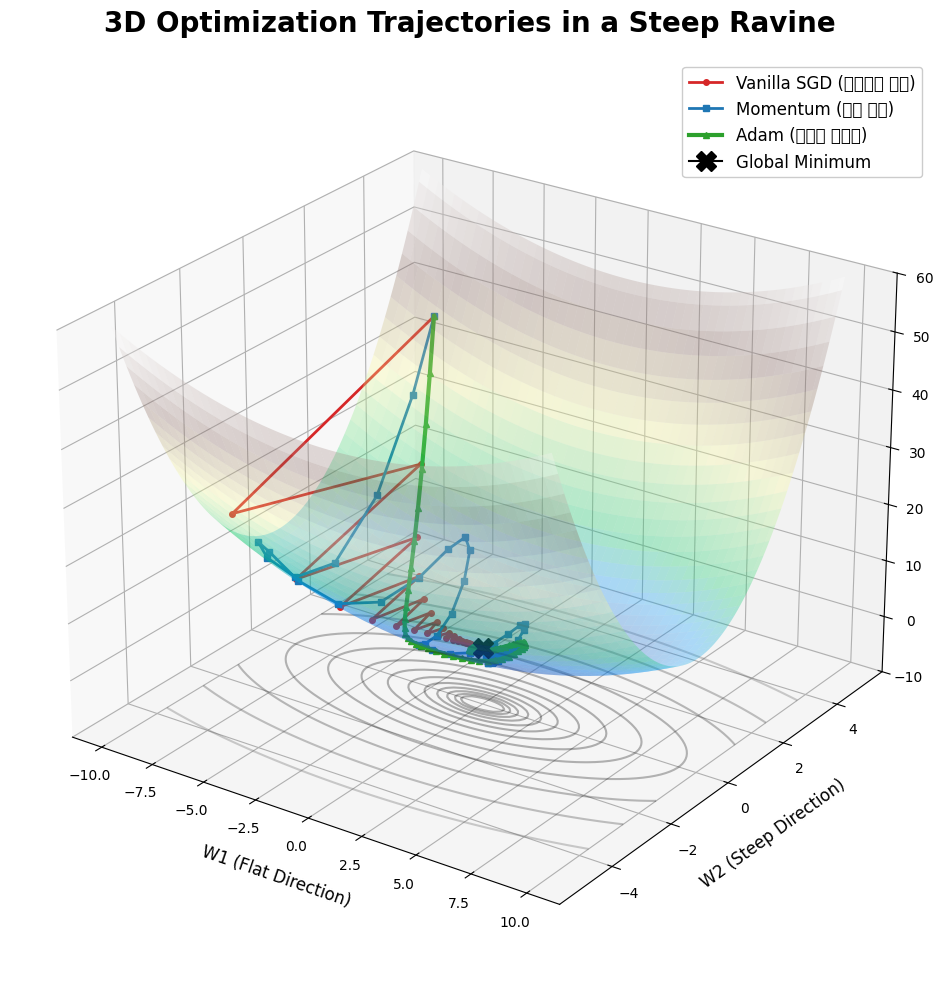

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # 3D 투영을 위한 임포트

# 1. 손실 함수 (Pathological Curvature - 깊은 협곡 지형)
# Y축으로는 매우 가파르고, X축으로는 매우 완만한 형태
def loss_func(x, y):
    return (1/10) * x**2 + 2 * y**2

# 기울기(Gradient) 계산
def gradient(x, y):
    return np.array([0.2 * x, 4 * y])

# 배경 3D 표면 및 등고선 데이터 생성
x_grid, y_grid = np.meshgrid(np.linspace(-10, 10, 100), np.linspace(-5, 5, 100))
z_grid = loss_func(x_grid, y_grid)

# 시뮬레이션 초기 설정
start_point = np.array([-8.0, 4.0])
iterations = 60

# ---------------------------------------------------------
# 1. Vanilla SGD: 가파른 곳(Y)에서 진동하고, 완만한 곳(X)에서 느림
sgd_path = [start_point]
w = start_point.copy()
lr_sgd = 0.45  # SGD의 지그재그 패턴이 잘 보이도록 세팅
for _ in range(iterations):
    grad = gradient(w[0], w[1])
    w = w - lr_sgd * grad
    sgd_path.append(w.copy())

# 2. Momentum: 진동을 뚫고 가속도(관성)를 받아 빠르게 돌진
momentum_path = [start_point]
w = start_point.copy()
v = np.zeros(2)
lr_mom = 0.05
beta_mom = 0.9
for _ in range(iterations):
    grad = gradient(w[0], w[1])
    v = beta_mom * v + lr_mom * grad
    w = w - v
    momentum_path.append(w.copy())

# 3. Adam: 방향별로 보폭을 조절하여 최단 거리로 스무스하게 하강
adam_path = [start_point]
w = start_point.copy()
m = np.zeros(2)
v_acc = np.zeros(2)
lr_adam = 0.5
beta1, beta2 = 0.9, 0.999
epsilon = 1e-8
for t in range(1, iterations + 1):
    grad = gradient(w[0], w[1])
    m = beta1 * m + (1 - beta1) * grad
    v_acc = beta2 * v_acc + (1 - beta2) * (grad**2)
    m_hat = m / (1 - beta1**t)
    v_hat = v_acc / (1 - beta2**t)
    w = w - lr_adam * m_hat / (np.sqrt(v_hat) + epsilon)
    adam_path.append(w.copy())

# 배열 변환
sgd_path = np.array(sgd_path)
momentum_path = np.array(momentum_path)
adam_path = np.array(adam_path)

# Z축(Loss 값) 계산 (3D 공간에 경로를 띄우기 위해)
z_sgd = np.array([loss_func(p[0], p[1]) for p in sgd_path])
z_mom = np.array([loss_func(p[0], p[1]) for p in momentum_path])
z_adam = np.array([loss_func(p[0], p[1]) for p in adam_path])

# ---------------------------------------------------------
# 시각화 (3D Plotting)
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# 반투명한 3D 계곡 표면 그리기
surf = ax.plot_surface(x_grid, y_grid, z_grid, cmap='terrain', alpha=0.3, edgecolor='none')

# 바닥(z=-10)에 2D 등고선을 투영하여 입체감 극대화
ax.contour(x_grid, y_grid, z_grid, zdir='z', offset=-10, levels=np.logspace(-1, 2, 15), cmap='gray', alpha=0.3)

# 옵티마이저별 3D 궤적 그리기
ax.plot(sgd_path[:, 0], sgd_path[:, 1], z_sgd, 'o-', color='#d62728', label='Vanilla SGD (지그재그 진동)', markersize=4, linewidth=2)
ax.plot(momentum_path[:, 0], momentum_path[:, 1], z_mom, 's-', color='#1f77b4', label='Momentum (관성 가속)', markersize=4, linewidth=2)
ax.plot(adam_path[:, 0], adam_path[:, 1], z_adam, '^-', color='#2ca02c', label='Adam (안정적 최적화)', markersize=5, linewidth=3)

# 목표 지점 (Global Minimum)
ax.plot([0], [0], [0], marker='X', color='black', markersize=15, label='Global Minimum')

# 뷰 각도 조절 (계곡의 깊이와 경로가 가장 잘 보이는 각도)
ax.view_init(elev=25, azim=-55)

# 축 및 레이블 설정
ax.set_title('3D Optimization Trajectories in a Steep Ravine', fontsize=20, fontweight='bold', pad=20)
ax.set_xlabel('W1 (Flat Direction)', fontsize=12, labelpad=10)
ax.set_ylabel('W2 (Steep Direction)', fontsize=12, labelpad=10)
ax.set_zlabel('Loss', fontsize=12, labelpad=10)
ax.set_zlim(-10, np.max(z_grid))

# 범례
ax.legend(fontsize=12, loc='upper right', framealpha=1.0)

plt.tight_layout()
plt.savefig('optimizer_3d_trajectories.png', dpi=300, bbox_inches='tight')
plt.show()